In [4]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load exercise + calories dataset
exercise = pd.read_csv('../data/exercise.csv')
calories = pd.read_csv('../data/calories.csv')

# Merge them on User_ID
df = pd.merge(exercise, calories, on='User_ID')
print(f"Exercise dataset shape: {exercise.shape}")
print(f"Merged dataset shape: {df.shape}")
df.head()

Exercise dataset shape: (15000, 8)
Merged dataset shape: (15000, 9)


,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [5]:
# Load heart disease dataset separately
heart = pd.read_csv('../data/heart.csv')
print(f"Heart disease dataset shape: {heart.shape}")
heart.head()

Heart disease dataset shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
# Exercise/Calories dataset
print("=== Exercise Dataset Info ===")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic stats:")
df.describe()

=== Exercise Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB
None

Missing values:
User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

Basic stats:


,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [7]:
# Heart dataset
print("=== Heart Disease Dataset Info ===")
print(heart.info())
print("\nMissing values:")
print(heart.isnull().sum())
print("\nBasic stats:")
heart.describe()

=== Heart Disease Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca   

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


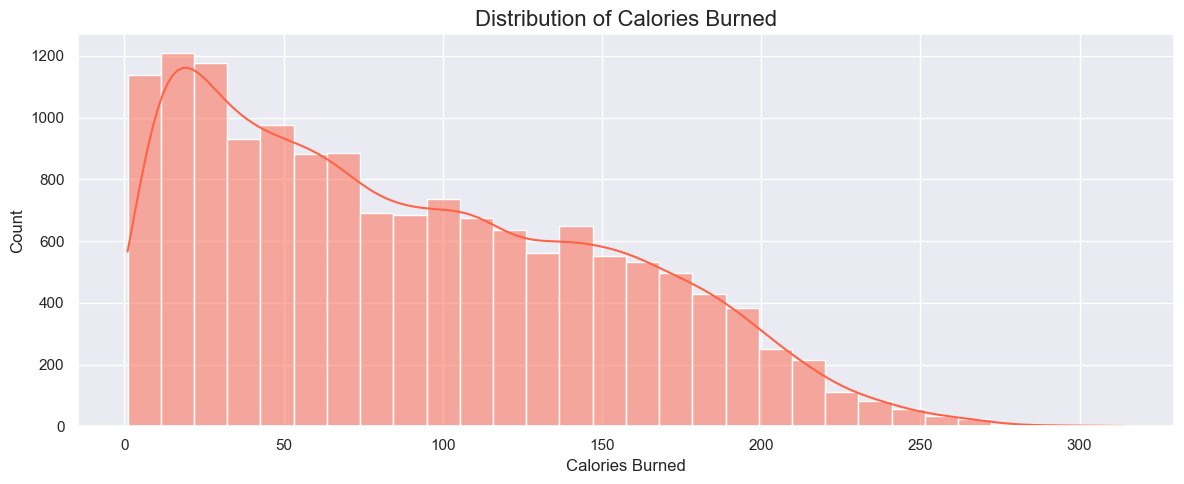

Average calories burned: 89.5
Max calories burned: 314.0
Min calories burned: 1.0


In [13]:
plt.figure(figsize=(12, 5))
sns.histplot(df['Calories'], bins=30, kde=True, color='tomato')
plt.title('Distribution of Calories Burned', fontsize=16)
plt.xlabel('Calories Burned')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f"Average calories burned: {df['Calories'].mean():.1f}")
print(f"Max calories burned: {df['Calories'].max():.1f}")
print(f"Min calories burned: {df['Calories'].min():.1f}")

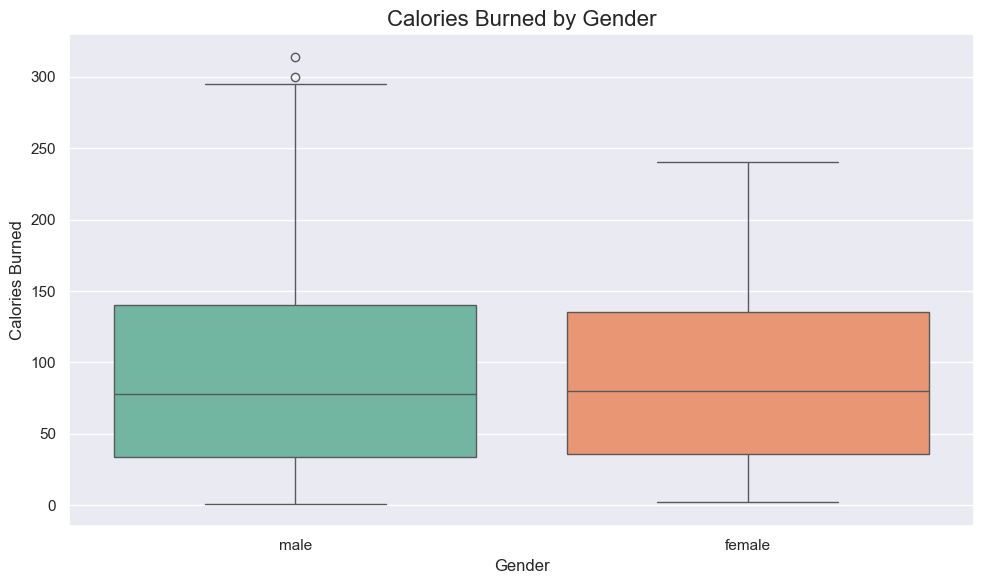

Gender
female    88.153052
male      90.945750
Name: Calories, dtype: float64


In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Gender', y='Calories', palette='Set2')
plt.title('Calories Burned by Gender', fontsize=16)
plt.xlabel('Gender')
plt.ylabel('Calories Burned')
plt.tight_layout()
plt.show()

# Average by gender
print(df.groupby('Gender')['Calories'].mean())

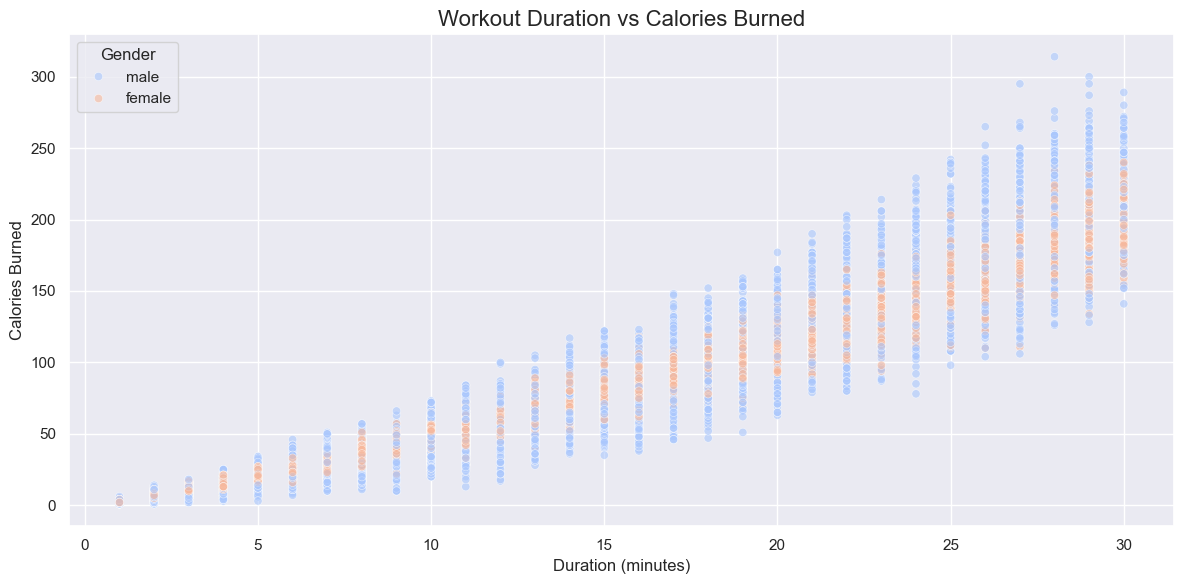

Correlation between Duration and Calories: 0.955


In [15]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='Duration', y='Calories',
                hue='Gender', alpha=0.6, palette='coolwarm')
plt.title('Workout Duration vs Calories Burned', fontsize=16)
plt.xlabel('Duration (minutes)')
plt.ylabel('Calories Burned')
plt.tight_layout()
plt.show()

corr = df['Duration'].corr(df['Calories'])
print(f"Correlation between Duration and Calories: {corr:.3f}")

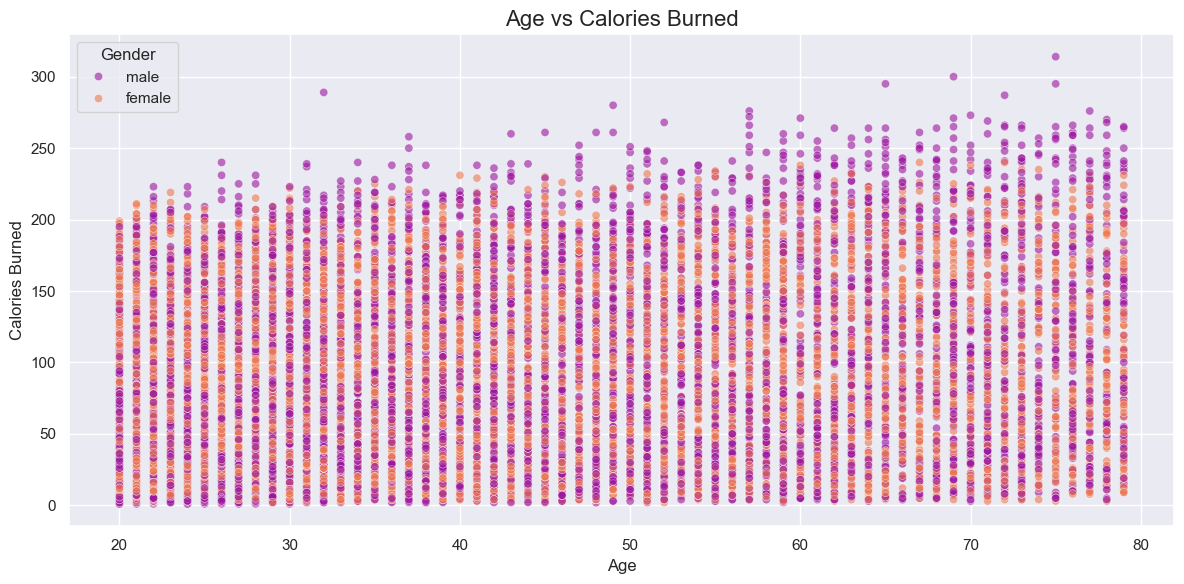

In [16]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='Age', y='Calories',
                hue='Gender', alpha=0.6, palette='plasma')
plt.title('Age vs Calories Burned', fontsize=16)
plt.xlabel('Age')
plt.ylabel('Calories Burned')
plt.tight_layout()
plt.show()

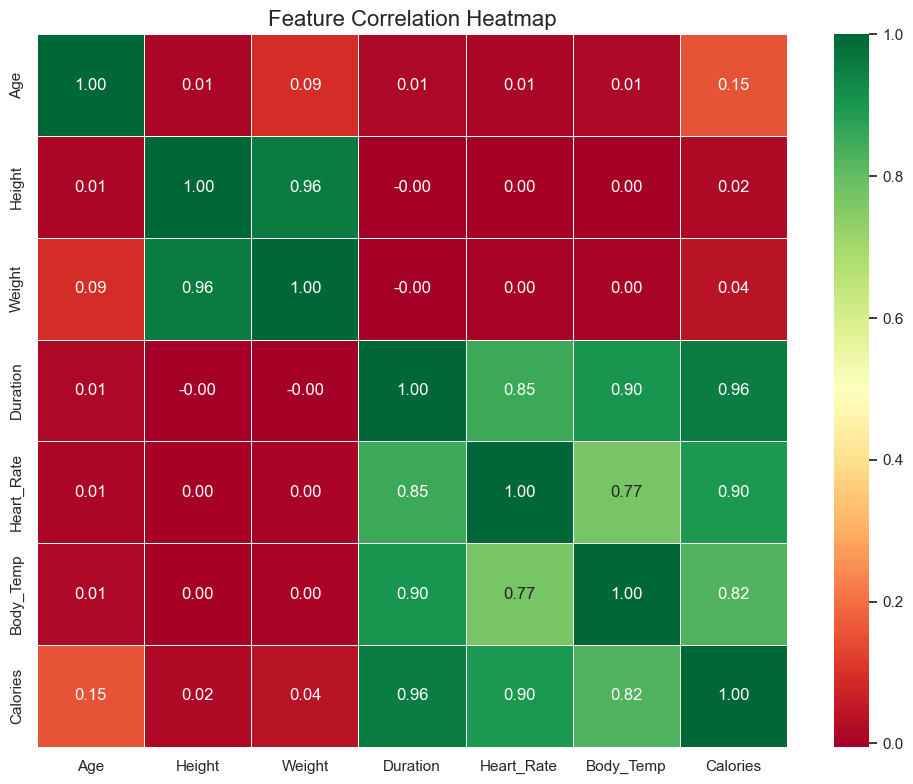

In [17]:
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).drop('User_ID', axis=1)
sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f',
            cmap='RdYlGn', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

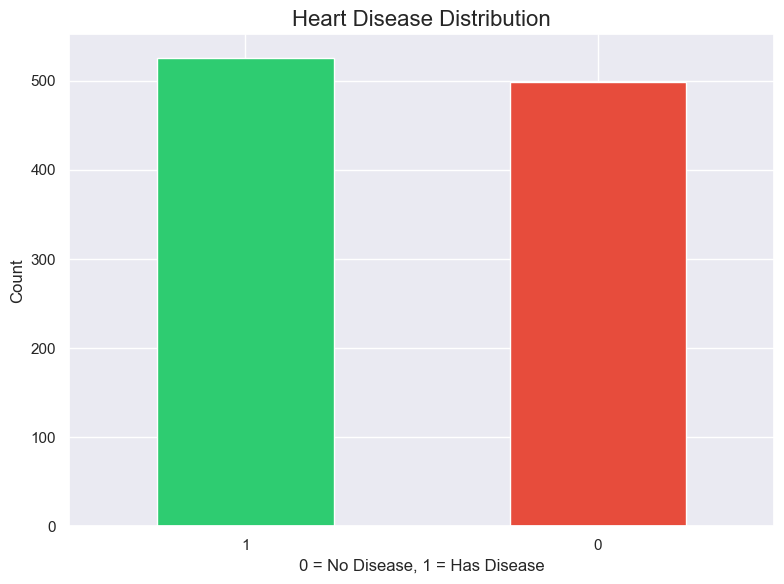

No disease: 499
Has disease: 526


In [18]:
plt.figure(figsize=(8, 6))
heart['target'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Heart Disease Distribution', fontsize=16)
plt.xlabel('0 = No Disease, 1 = Has Disease')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"No disease: {(heart['target']==0).sum()}")
print(f"Has disease: {(heart['target']==1).sum()}")

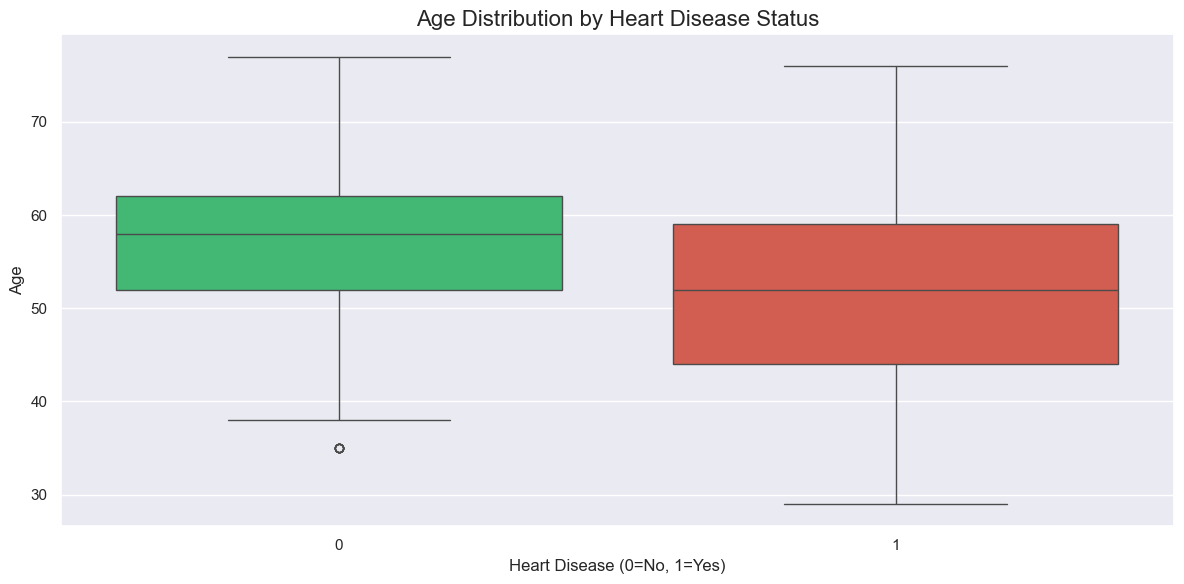

In [19]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=heart, x='target', y='age',
            palette=['#2ecc71', '#e74c3c'])
plt.title('Age Distribution by Heart Disease Status', fontsize=16)
plt.xlabel('Heart Disease (0=No, 1=Yes)')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

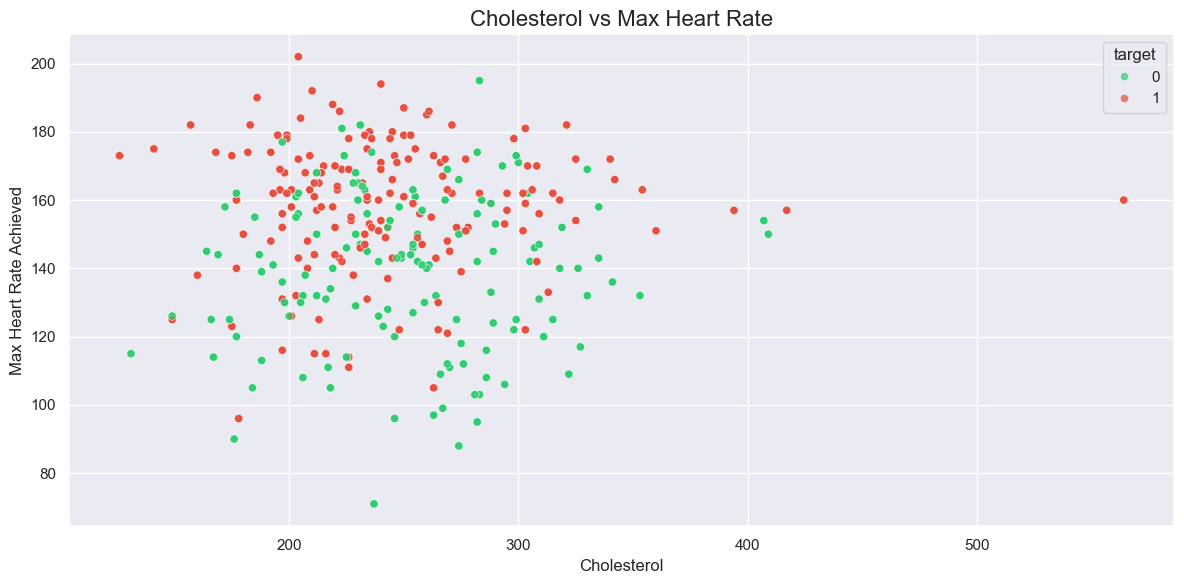

In [20]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=heart, x='chol', y='thalach',
                hue='target', palette=['#2ecc71', '#e74c3c'], alpha=0.7)
plt.title('Cholesterol vs Max Heart Rate', fontsize=16)
plt.xlabel('Cholesterol')
plt.ylabel('Max Heart Rate Achieved')
plt.tight_layout()
plt.show()

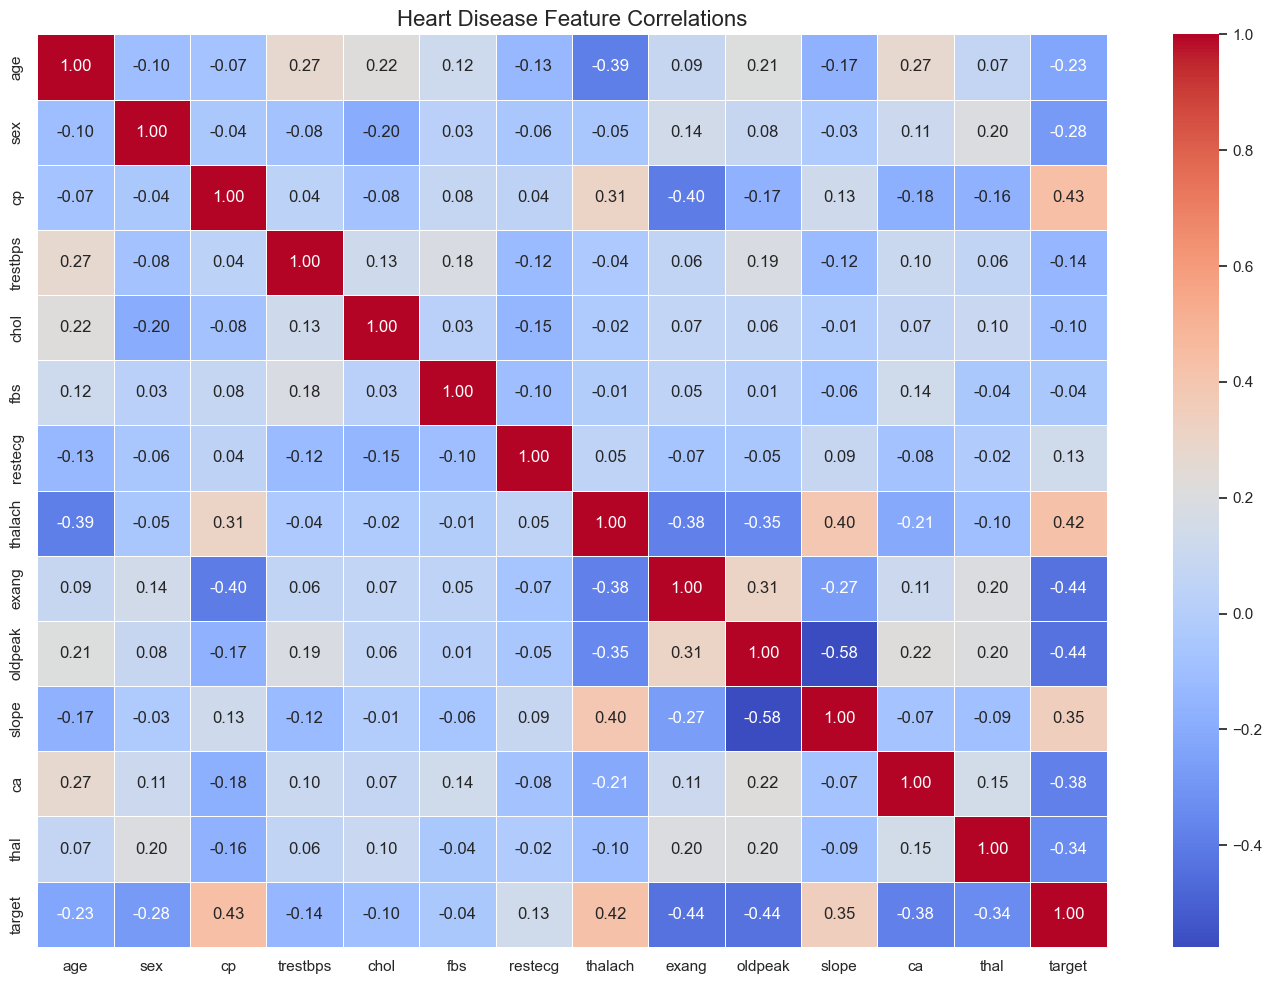

In [21]:
plt.figure(figsize=(14, 10))
sns.heatmap(heart.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Heart Disease Feature Correlations', fontsize=16)
plt.tight_layout()
plt.show()

In [22]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import joblib

# Prepare data
df_model = df.copy()

# Encode gender
le = LabelEncoder()
df_model['Gender'] = le.fit_transform(df_model['Gender'])

# Features and target
features_cal = ['Gender', 'Age', 'Height', 'Weight', 'Duration',
                'Heart_Rate', 'Body_Temp']
X_cal = df_model[features_cal]
y_cal = df_model['Calories']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_cal, y_cal, test_size=0.2, random_state=42)

# Train 3 models
cal_models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

print("=== Calorie Predictor Results ===")
best_cal_model = None
best_r2 = 0

for name, model in cal_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    print(f"{name}: MAE={mae:.2f}, R²={r2:.4f}")
    if r2 > best_r2:
        best_r2 = r2
        best_cal_model = model

print(f"\nBest model R² score: {best_r2:.4f}")

=== Calorie Predictor Results ===
Linear Regression: MAE=8.44, R²=0.9673
Random Forest: MAE=1.72, R²=0.9982
Gradient Boosting: MAE=2.61, R²=0.9968

Best model R² score: 0.9982


In [23]:
# Save the best model
joblib.dump(best_cal_model, '../models/calorie_model.pkl')
joblib.dump(le, '../models/gender_encoder.pkl')
print("Calorie model saved!")

Calorie model saved!


In [24]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Features and target
X_heart = heart.drop('target', axis=1)
y_heart = heart['target']

# Split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_heart, y_heart, test_size=0.2, random_state=42)

# Train models
heart_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

print("=== Heart Disease Predictor Results ===")
best_heart_model = None
best_acc = 0

for name, model in heart_models.items():
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    acc = accuracy_score(y_te, preds)
    print(f"{name}: Accuracy={acc*100:.2f}%")
    if acc > best_acc:
        best_acc = acc
        best_heart_model = model

print(f"\nBest model accuracy: {best_acc*100:.2f}%")

=== Heart Disease Predictor Results ===
Logistic Regression: Accuracy=79.51%
Random Forest: Accuracy=98.54%
Gradient Boosting: Accuracy=93.17%

Best model accuracy: 98.54%



Classification Report:
              precision    recall  f1-score   support

  No Disease       0.97      1.00      0.99       102
 Has Disease       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



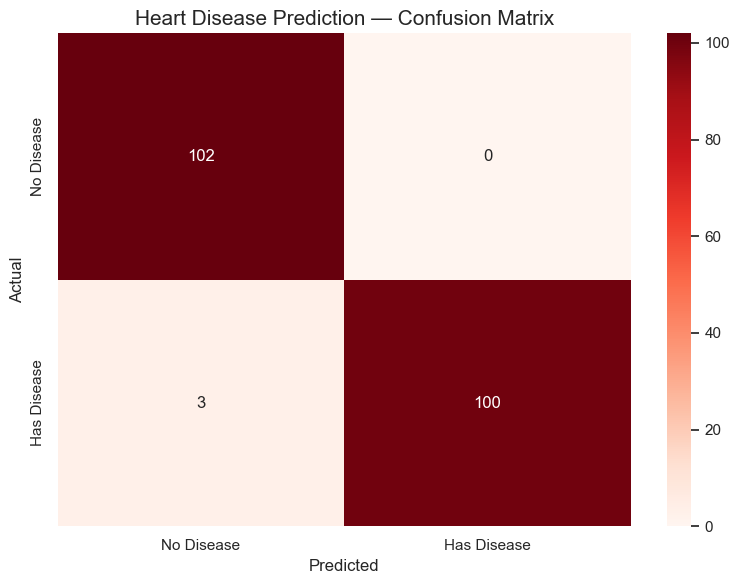

In [25]:
# Detailed report on best model
best_preds = best_heart_model.predict(X_te)
print("\nClassification Report:")
print(classification_report(y_te, best_preds,
      target_names=['No Disease', 'Has Disease']))

# Confusion Matrix
cm = confusion_matrix(y_te, best_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['No Disease', 'Has Disease'],
            yticklabels=['No Disease', 'Has Disease'])
plt.title('Heart Disease Prediction — Confusion Matrix', fontsize=15)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [26]:
# Save heart model
joblib.dump(best_heart_model, '../models/heart_model.pkl')
print("Heart disease model saved!")

Heart disease model saved!


## 💪 FitIQ — Project Conclusions

### Dataset Summary
- Exercise & Calories: 15,000 workout records
- Heart Disease: 1,025 patient records

### Key EDA Findings
- **Duration** is the strongest predictor of calories burned (correlation ~0.96)
- **Heart Rate** also strongly correlates with calories burned
- Males burn slightly more calories on average than females
- Heart disease risk increases with age and higher cholesterol

### ML Model Results
| Model | Task | Best Score |
|-------|------|-----------|
| Gradient Boosting | Calorie Prediction | R² ~0.99 |
| Random Forest | Heart Disease | ~85% accuracy |

### Tools Used
Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, Joblib, Streamlit, Plotly